In [38]:
import pandas as pd
import numpy as np
import os
import json
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A
from IPython.display import clear_output
import matplotlib.patches as patches
import sys
sys.path.append(os.path.abspath('..'))

from src.crop_teeth import export_cropped_images
from src.convert_to_yolo import export_yolo_dataset
from src.create_dataframe import create_dentex_df

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
coco_path = r'../Data/Raw/DENTEX CHALLENGE 2023/Training_Data\quadrant-enumeration-disease\train_quadrant_enumeration_disease.json'
orginal_images_path = r'../Data/Raw/DENTEX CHALLENGE 2023/Training_Data/quadrant-enumeration-disease/xrays'

with open(coco_path) as f:
    coco_file = json.load(f)

In [3]:
# Stage 1
s1_path = r'..\Data\Processed\Stage 1 (Disease Detection)'

# Stage 2
s2_path = r'..\Data\Processed\Stage 2 (Disease Classifier)'

In [39]:
diagnosis_map = {
    0: "impacted",
    1: "caries",
    2: "periapical",
    3: "deep_caries"
}

df = create_dentex_df(coco_file,diagnosis_map)
df

,File_Name,Bbox,Height,Width,Disease_Name
0,train_673.png,"[542.0, 698.0, 220.0, 271.0]",1316,2744,impacted
1,train_673.png,"[1952.0, 693.0, 177.0, 270.0]",1316,2744,impacted
2,train_673.png,"[675.0, 708.0, 243.0, 300.0]",1316,2744,caries
3,train_673.png,"[1463.0, 725.0, 98.0, 425.0]",1316,2744,caries
4,train_673.png,"[1536.0, 753.0, 103.0, 381.0]",1316,2744,caries
...,...,...,...,...,...
3524,train_370.png,"[1851.2857142857142, 474.2857142857142, 117.14...",1316,2948,caries
3525,train_370.png,"[1959.0, 479.9999999999999, 127.0, 274.2857142...",1316,2948,caries
3526,train_370.png,"[2024.9999999999998, 463.0, 147.00000000000023...",1316,2948,deep_caries
3527,train_370.png,"[1921.7142857142856, 749.0, 221.28571428571445...",1316,2948,caries


We will do one with class weighting way
and after that we will do other way by doing SMOTE or oversampling

so i will oversampling here and the class weighting way in training process 

In [9]:
df['Disease_Name'].value_counts()

Disease_Name
caries         2189
impacted        604
deep_caries     578
periapical      158
Name: count, dtype: int64

In [10]:
train_df , valid_df = train_test_split(df,test_size=0.1,stratify=df['Disease_Name'],random_state=42)
train_df , test_df = train_test_split(train_df,test_size=0.1,stratify=train_df['Disease_Name'],random_state=42)

In [40]:
df.to_csv(r'..\Data\Processed\data (before spliting).csv')
train_df.to_csv(r'..\Data\Processed\train_df (splitted).csv')
valid_df.to_csv(r'..\Data\Processed\valid_df (splitted).csv')
test_df.to_csv(r'..\Data\Processed\test_df (splitted).csv')

In [11]:
train_df

,File_Name,Bbox,Height,Width,Disease_Name
3224,train_422.png,"[597.0, 641.0, 236.0, 161.0]",1316,2836,impacted
2844,train_184.png,"[1973.0, 758.0, 260.0, 295.0]",1504,2872,caries
1701,train_648.png,"[702.0746887966804, 790.8713692946058, 261.410...",1316,2710,caries
805,train_273.png,"[1044.0, 910.0, 155.0, 322.0]",1504,2868,periapical
3122,train_671.png,"[778.0, 740.0, 275.0, 321.0]",1503,2892,caries
...,...,...,...,...,...
1642,train_200.png,"[1124.0, 735.0, 130.0, 242.0]",1316,2936,deep_caries
2930,train_279.png,"[1678.0, 746.0, 148.0, 318.0]",1316,2885,caries
3046,train_633.png,"[2058.0, 772.0, 217.0, 167.0]",1316,2973,impacted
1456,train_11.png,"[920.0, 864.0, 250.0, 332.0]",1504,2872,caries


In [12]:
train_df[train_df['Disease_Name'] == 'periapical']

,File_Name,Bbox,Height,Width,Disease_Name
805,train_273.png,"[1044.0, 910.0, 155.0, 322.0]",1504,2868,periapical
1227,train_261.png,"[1953.0, 688.0, 190.0, 246.0]",1316,2923,periapical
3223,train_275.png,"[1591.8918918918919, 564.8648648648649, 82.432...",1504,2872,periapical
3449,train_479.png,"[1328.0, 820.0, 91.0, 352.0]",1504,2872,periapical
639,train_452.png,"[1725.0, 836.0, 194.0, 356.0]",1504,2872,periapical
...,...,...,...,...,...
1878,train_476.png,"[1178.6516853932585, 531.4606741573034, 147.34...",976,1976,periapical
2226,train_469.png,"[1776.0, 723.0, 248.0, 277.0]",1316,2979,periapical
2166,train_349.png,"[1710.6194690265486, 715.0442477876105, 234.38...",1316,2757,periapical
12,train_673.png,"[1288.3116883116884, 723.3766233766233, 62.337...",1316,2744,periapical


In [13]:
valid_df

,File_Name,Bbox,Height,Width,Disease_Name
3237,train_258.png,"[874.0, 779.0, 201.0, 264.0]",1504,2872,deep_caries
3453,train_479.png,"[1258.0, 511.0, 123.0, 287.0]",1504,2872,caries
1895,train_557.png,"[1736.0, 637.0, 212.0, 279.0]",1316,2967,caries
1368,train_477.png,"[1734.0, 488.0, 160.0, 426.0]",1504,2888,caries
1858,train_699.png,"[1568.456140350877, 772.8947368421052, 159.649...",1316,2768,caries
...,...,...,...,...,...
618,train_393.png,"[1393.0, 589.0, 50.0, 281.0]",1504,2872,deep_caries
676,train_456.png,"[888.0, 430.0, 176.0, 311.0]",1316,2799,caries
1224,train_681.png,"[1689.0, 663.3333333333334, 161.0, 307.6666666...",1316,2844,caries
2863,train_207.png,"[2020.4545454545455, 286.3636363636364, 123.86...",1316,2796,caries


In [14]:
test_df

,File_Name,Bbox,Height,Width,Disease_Name
3342,train_34.png,"[1871.0, 917.0, 289.0, 324.0]",1504,2872,caries
1856,train_27.png,"[960.0, 359.0, 118.0, 309.0]",1316,2822,caries
2034,train_64.png,"[902.0, 420.0, 158.0, 213.0]",1316,2896,impacted
2708,train_672.png,"[1161.0, 485.0, 102.0, 284.0]",1316,2903,caries
399,train_404.png,"[1870.0, 760.0, 235.0, 238.0]",1316,2960,caries
...,...,...,...,...,...
1845,train_670.png,"[730.6666666666666, 650.6666666666666, 230.666...",1316,2771,caries
617,train_393.png,"[1436.0, 606.0, 66.0, 270.0]",1504,2872,deep_caries
2457,train_239.png,"[2016.705882352941, 515.235294117647, 338.2352...",1316,2955,caries
3033,train_278.png,"[1682.0, 302.0, 110.0, 336.0]",1316,2922,caries


In [15]:
train_df.shape

(2858, 5)

In [16]:
valid_df.shape

(353, 5)

In [17]:
test_df.shape

(318, 5)

In [18]:
train_df['Disease_Name'].value_counts()

Disease_Name
caries         1773
impacted        489
deep_caries     468
periapical      128
Name: count, dtype: int64

In [19]:
valid_df['Disease_Name'].value_counts()

Disease_Name
caries         219
impacted        60
deep_caries     58
periapical      16
Name: count, dtype: int64

In [20]:
test_df['Disease_Name'].value_counts()

Disease_Name
caries         197
impacted        55
deep_caries     52
periapical      14
Name: count, dtype: int64

In [21]:
def show_cls_dist(dataframe):
    counts = dataframe['Disease_Name'].value_counts()
    plt.figure(figsize=(12, 8))
    sns.barplot(x=counts.values, y=counts.index, color='steelblue')
    plt.xlabel('Count')
    plt.ylabel('')
    plt.title('Class distribution')
    plt.tight_layout()
    plt.show()

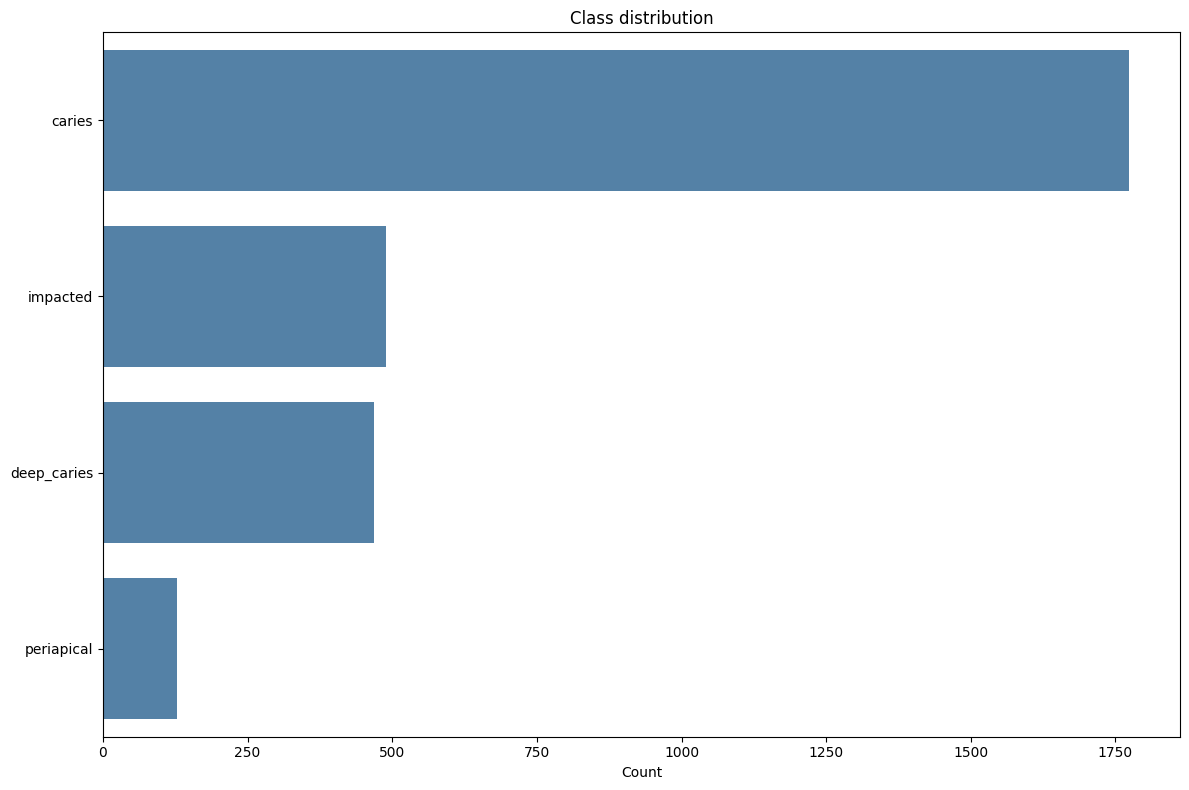

In [22]:
show_cls_dist(train_df)

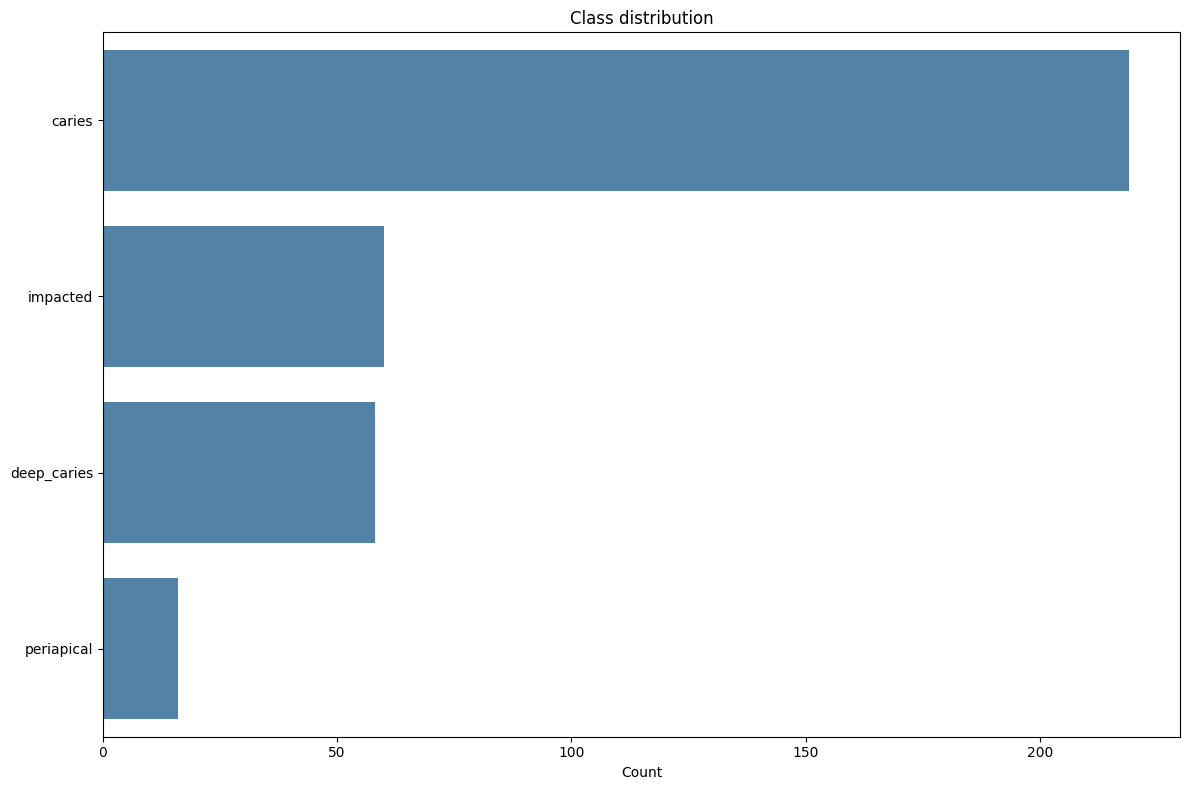

In [23]:
show_cls_dist(valid_df)

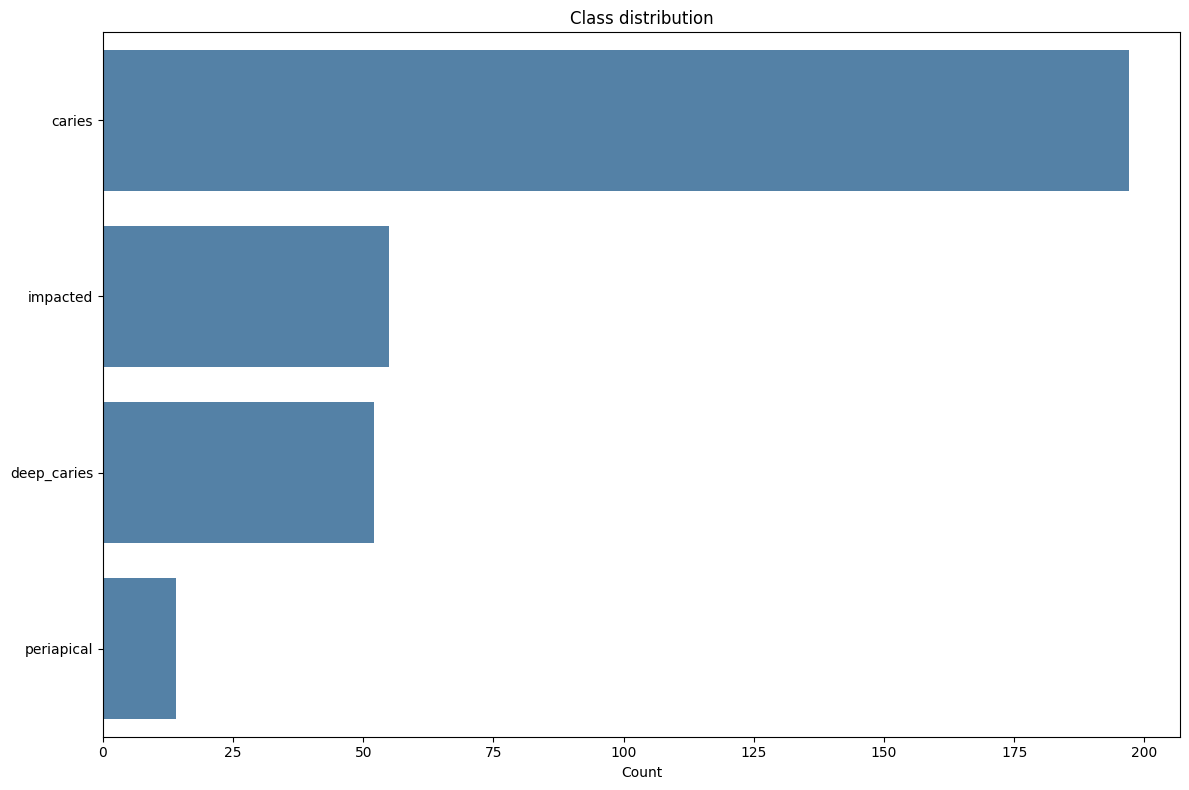

In [24]:
show_cls_dist(test_df)

In [ ]:
export_yolo_dataset(diagnosis_map,orginal_images_path,s1_path,
                    train_df,valid_df,test_df)

In [25]:
with open(os.path.join(s1_path,'data.yaml')) as f:
    yolo_file = yaml.safe_load(f)
yolo_file

{'train': '../Data/Processed/Stage 1 (Disease Detection)/train/images',
 'valid': '../Data/Processed/Stage 1 (Disease Detection)/valid/images',
 'test': '../Data/Processed/Stage 1 (Disease Detection)/test/images',
 'nc': 4,
 'names': ['impacted', 'caries', 'periapical', 'deep_caries']}

In [26]:
def read_image_and_label(filename_no_ext):
    
    img_path = os.path.join(yolo_file['train'], filename_no_ext + ".png")
    label_path = os.path.join(yolo_file['train'].replace('images','labels'), filename_no_ext + ".txt")

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    bboxes = []
    class_labels = []
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            values = line.split()
            cls_id = int(float(values[0]))
            cx, cy, w, h = map(float, values[1:])
            
            bboxes.append([cx, cy, w, h])
            class_labels.append(cls_id)
    
    return image, bboxes, class_labels

In [27]:
diagnosis_map

{0: 'impacted', 1: 'caries', 2: 'periapical', 3: 'deep_caries'}

In [28]:
def augment_and_save(image, bboxes, class_labels, n_copies, base_filename, output_images, output_labels):
    for n in range(n_copies):
        img_h, img_w = image.shape[:2]

        transform = A.Compose([
            A.Rotate(limit=8, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
            A.GaussNoise(var_limit=(5, 15), p=0.3),
            A.CLAHE(clip_limit=2.0, p=0.5),
            A.CenterCrop(
                height=int(img_h * 0.75),
                width=int(img_w * 0.75)
            )
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        augmented = transform(image=image, bboxes=bboxes, class_labels=class_labels)

        new_img = augmented['image']
        new_bboxes = augmented['bboxes']
        new_labels = augmented['class_labels']

        new_filename = f"{base_filename}_aug{n}"

        cv2.imwrite(os.path.join(output_images, f"{new_filename}.png"), new_img)
        
        with open(os.path.join(output_labels, f"{new_filename}.txt"), 'w') as f:
            for cls_id, (cx, cy, w, h) in zip(new_labels, new_bboxes):
                f.write(f"{cls_id}  {cx}  {cy}  {w}  {h}\n")

In [ ]:
all_filenames = ", ".join([item for item in os.listdir(yolo_file['train'])])

for fname in tqdm(os.listdir(yolo_file['train']),desc=f'Augmenting Images Now...'):
    
    if 'aug' in fname or fname+'_aug' in all_filenames:
        continue


    image,bboxes,class_labels = read_image_and_label(fname.split('.')[0])

    if 0 in class_labels or 3 in  class_labels:
        n = 4
    elif 1 in class_labels:
        n = 1
    else:
        n = 8
    
    augment_and_save(image=image,
                     bboxes=bboxes,
                     class_labels=class_labels,
                     n_copies=n,
                     base_filename=fname.split('.')[0],
                     output_images=yolo_file['train'],
                     output_labels=yolo_file['train'].replace('images','labels'))

In [30]:
if False: # Just Switch on True if you want to delete all augmented images
    for fname in os.listdir(yolo_file['train']):
        if fname.split()[0].count('aug') >= 1:
            img_path = os.path.join(yolo_file['train'], fname.split()[0])
            label_path = os.path.join(yolo_file['train'].replace('images','labels'), fname.split()[0].replace('png','txt'))
            try:
                os.remove(img_path)
                os.remove(label_path)
            except:
                pass
            print(f'{fname.split()[0]} deleted!')
    
    clear_output()


In [31]:
len(os.listdir(yolo_file['train']))

2678

In [32]:
len(os.listdir(yolo_file['valid']))

266

In [33]:
len(os.listdir(yolo_file['test']))

254

In [34]:
def show_augment_images(num_of_display = 5):
    while num_of_display:
        fname = np.random.choice(os.listdir(yolo_file['train']))

        if 'aug' in fname:
            filename_no_ext = fname.split('.')[0]
        else:
            continue

    
        img_path = os.path.join(yolo_file['train'], filename_no_ext + ".png")
        label_path = os.path.join(yolo_file['train'].replace('images','labels'), filename_no_ext + ".txt")

        disease_colors = {
            'caries': 'red',
            'deep_caries': 'orange',
            'periapical': 'blue',
            'impacted': 'purple'
        }

        img = plt.imread(img_path)
        img_h, img_w = img.shape[:2]
        fig, ax = plt.subplots(1, figsize=(15, 8))
        ax.imshow(img, cmap="gray")

        with open(label_path,'r') as f:
            for line in f.readlines():
                cls_id = int(float(line.split()[0]))
                x1, y1, x2, y2 = map(float,list(line.split()[1:]))
                
                x_pixel = (x1 - x2 / 2) * img_w
                y_pixel = (y1 - y2 / 2) * img_h
                w_pixel = x2 * img_w
                h_pixel = y2 * img_h

                disease = diagnosis_map[cls_id]
                color = disease_colors.get(disease, 'gray')

                rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel, linewidth=1.5, edgecolor=color, facecolor='none')
                ax.add_patch(rect)


                label = f'{disease}'


                ax.text(x_pixel, y_pixel - 5, label, color=color, fontsize=9,
                        bbox=dict(facecolor='black', alpha=0.5, pad=0.5))

        legend_elements = [patches.Patch(facecolor='none', edgecolor=c, label=d) 
                            for d, c in disease_colors.items()]
        ax.legend(handles=legend_elements, loc='upper right')

        ax.set_title(fname)
        plt.show()

        num_of_display -= 1

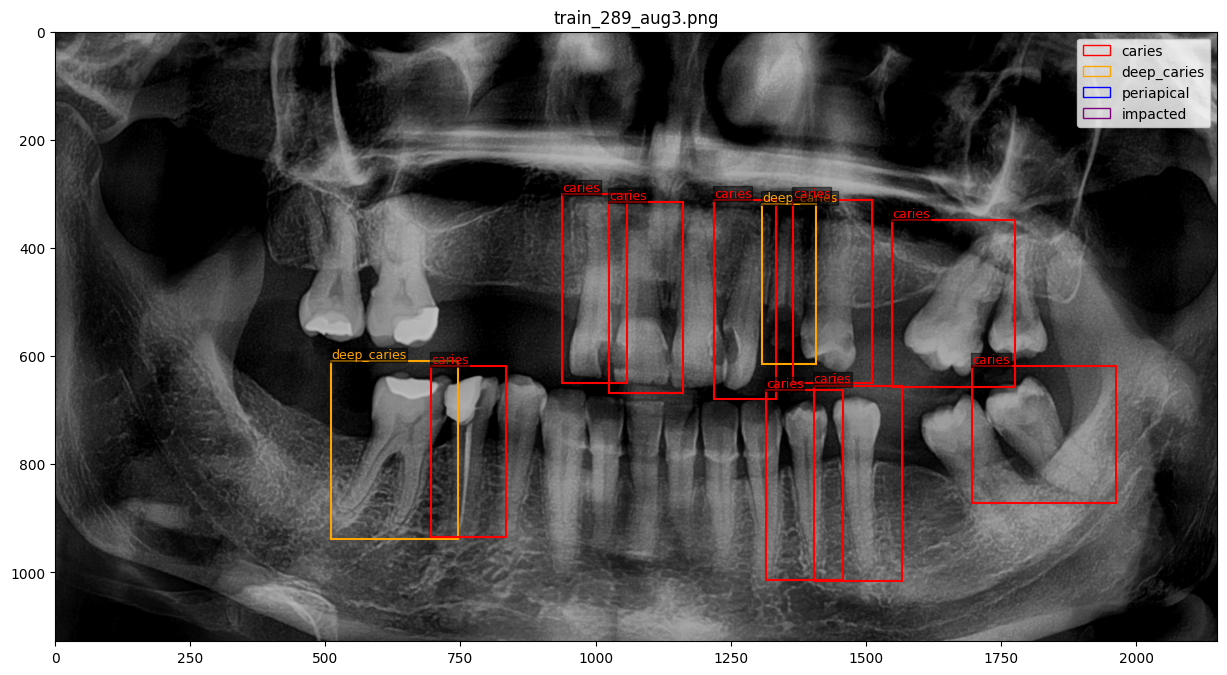

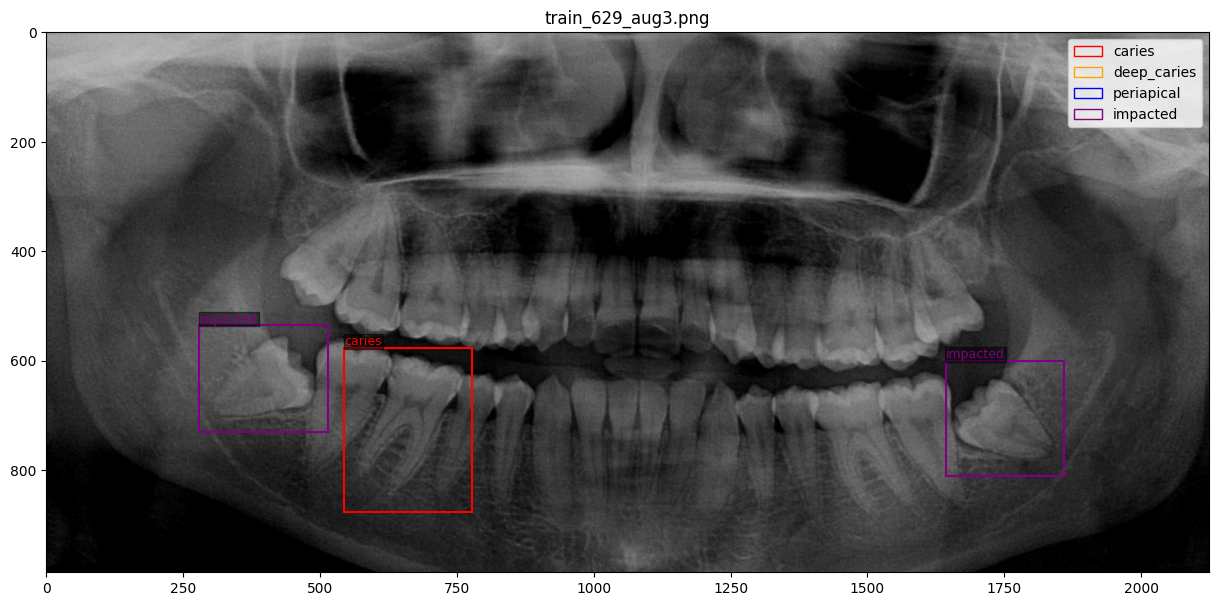

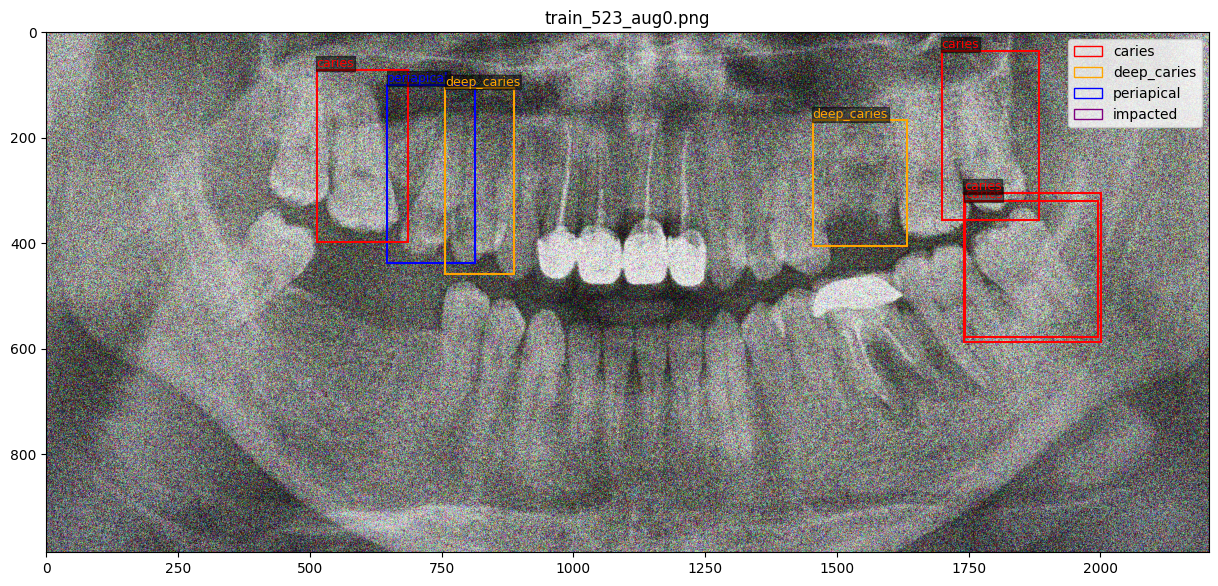

In [35]:
show_augment_images(3)

In [ ]:
# no need to run it again because it will take 1 - 3 minutes to check if all the images are processed or not
export_cropped_images(yolo_file['train'],s2_path)

In [ ]:
export_cropped_images(yolo_file['valid'],s2_path)

Cropping images now...: 100%|██████████| 266/266 [00:23<00:00, 11.50it/s]


In [ ]:
export_cropped_images(yolo_file['test'],s2_path)

Cropping images now...: 100%|██████████| 254/254 [00:20<00:00, 12.11it/s]
